In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

customers = pd.read_csv('data/customers.csv')
policies  = pd.read_csv('data/policies.csv')
claims    = pd.read_csv('data/claims.csv')

# Basic structure
print(customers.shape)
print(customers.dtypes)
print(customers.describe())

# Missing values
print(customers.isnull().sum())
print(policies.isnull().sum())
print(claims.isnull().sum())

(300, 6)
customer_id        object
name               object
age                 int64
region             object
years_licensed      int64
risk_score        float64
dtype: object
              age  years_licensed  risk_score
count  300.000000      300.000000  300.000000
mean    43.320000       21.730000    5.351333
std     15.326686       12.490683    2.577877
min     18.000000        1.000000    1.000000
25%     30.000000       11.000000    3.075000
50%     43.500000       22.000000    5.200000
75%     56.000000       32.000000    7.600000
max     69.000000       44.000000   10.000000
customer_id       0
name              0
age               0
region            0
years_licensed    0
risk_score        0
dtype: int64
policy_id         0
customer_id       0
product_type      0
start_date        0
end_date          0
annual_premium    0
status            0
dtype: int64
claim_id             0
policy_id            0
claim_date           0
claim_type           0
claimed_amount       0
approv

In [2]:
# Fix nulls in approved_amount - fill with 0 (no payout)
claims['approved_amount'] = claims['approved_amount'].fillna(0)

# Aggregate to customer level
claim_features = (
    policies
    .merge(claims, on='policy_id', how='left')
    .groupby('customer_id')
    .agg(
        total_policies=('policy_id',       'nunique'),
        total_claimed =('claimed_amount',  'sum'),
        total_approved=('approved_amount', 'sum'),
        n_claims      =('claim_id',        'count'),
        avg_premium   =('annual_premium',  'mean')
    )
    .reset_index()
)

# Merge with customer info
df = customers.merge(claim_features, on='customer_id', how='left')

# Target variable: 1 if customer has made at least one claim
df['has_claim'] = (df['n_claims'] > 0).astype(int)

print(df['has_claim'].value_counts())
# 1 → 166,  0 → 134

has_claim
1    166
0    134
Name: count, dtype: int64


In [ ]:
# customer_id를 X에서만 빼고 df엔 유지
policies['start_date'] = pd.to_datetime(policies['start_date'])
cutoff = pd.Timestamp('2023-01-01')

train_customers = policies[policies['start_date'] < cutoff]['customer_id'].unique()
test_customers  = policies[policies['start_date'] >= cutoff]['customer_id'].unique()

# get_dummies 이후에도 customer_id 남아있게
df = pd.get_dummies(df, columns=['region'])

drop_cols = ['customer_id', 'name', 'has_claim', 'n_claims', 'total_claimed', 'total_approved']
X = df.drop(columns=drop_cols)
y = df['has_claim']

# customer_id는 df에 아직 있으니 여기서 split
train_mask = df['customer_id'].isin(train_customers)
test_mask  = df['customer_id'].isin(test_customers)

X_train = X[train_mask]
y_train = y[train_mask]
X_test  = X[test_mask]
y_test  = y[test_mask]

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Train target balance: {y_train.mean():.2f}")
print(f"Test target balance:  {y_test.mean():.2f}")

Train: (229, 10), Test: (105, 10)
Train target balance: 0.57
Test target balance:  0.52


In [4]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(rf_model, X, y, cv=cv, scoring='roc_auc')

print(f"CV AUC: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")
# A high std here signals instability - likely due to small dataset size

CV AUC: 0.616 ± 0.035


In [5]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators':    [100, 200],
    'max_depth':       [3, 5, None],
    'min_samples_leaf':[1, 5, 10]
}

grid = GridSearchCV(rf_model, param_grid, cv=5, scoring='roc_auc', n_jobs=-1)
grid.fit(X_train, y_train)

print(f"Best params: {grid.best_params_}")
print(f"Best CV AUC: {grid.best_score_:.3f}")

best_rf = grid.best_estimator_

Best params: {'max_depth': 5, 'min_samples_leaf': 1, 'n_estimators': 200}
Best CV AUC: 0.668


In [6]:
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, classification_report

best_rf.fit(X_train, y_train)
y_pred_rf = best_rf.predict(X_test)
y_prob_rf = best_rf.predict_proba(X_test)[:, 1]

print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.3f}")
print(f"AUC:      {roc_auc_score(y_test, y_prob_rf):.3f}")
print(classification_report(y_test, y_pred_rf))
print(confusion_matrix(y_test, y_pred_rf))

Accuracy: 0.714
AUC:      0.784
              precision    recall  f1-score   support

           0       0.79      0.54      0.64        50
           1       0.68      0.87      0.76        55

    accuracy                           0.71       105
   macro avg       0.74      0.71      0.70       105
weighted avg       0.73      0.71      0.71       105

[[27 23]
 [ 7 48]]


In [7]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss'
)
xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

print(f"Accuracy: {accuracy_score(y_test, y_pred_xgb):.3f}")
print(f"AUC:      {roc_auc_score(y_test, y_prob_xgb):.3f}")
print(confusion_matrix(y_test, y_pred_xgb))

Accuracy: 0.762
AUC:      0.764
[[36 14]
 [11 44]]


In [8]:
from sklearn.metrics import precision_recall_curve
import numpy as np

precision, recall, thresholds = precision_recall_curve(y_test, y_prob_rf)

# Find threshold that maximises recall while keeping precision above 0.5
precision = precision[:-1]
recall    = recall[:-1]

valid = precision >= 0.5
if valid.any():
    best_threshold = thresholds[valid][np.argmax(recall[valid])]
else:
    best_threshold = 0.4

print(f"Selected threshold: {best_threshold:.2f}")

y_pred_adjusted = (y_prob_rf >= best_threshold).astype(int)

print("\n--- Default threshold (0.5) ---")
print(confusion_matrix(y_test, y_pred_rf))

print(f"\n--- Adjusted threshold ({best_threshold:.2f}) ---")
print(confusion_matrix(y_test, y_pred_adjusted))
print(classification_report(y_test, y_pred_adjusted))

Selected threshold: 0.26

--- Default threshold (0.5) ---
[[27 23]
 [ 7 48]]

--- Adjusted threshold (0.26) ---
[[ 0 50]
 [ 0 55]]
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        50
           1       0.52      1.00      0.69        55

    accuracy                           0.52       105
   macro avg       0.26      0.50      0.34       105
weighted avg       0.27      0.52      0.36       105



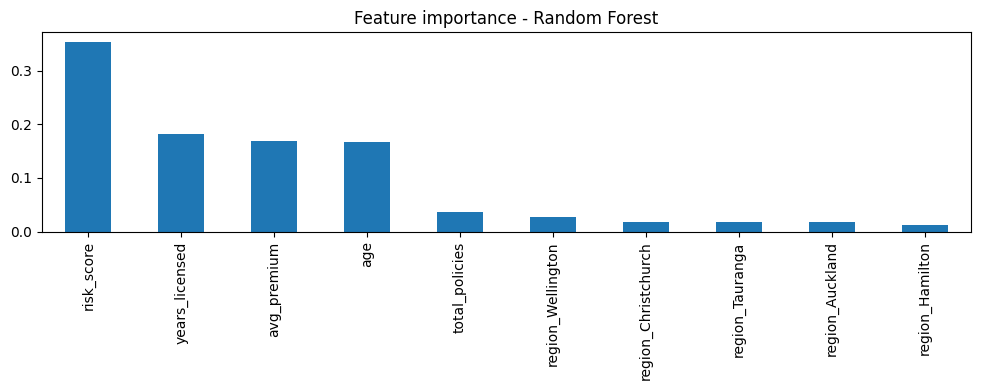

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

feat_imp = pd.Series(
    best_rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

feat_imp.plot(kind='bar', figsize=(10, 4))
plt.title('Feature importance - Random Forest')
plt.tight_layout()
plt.show()

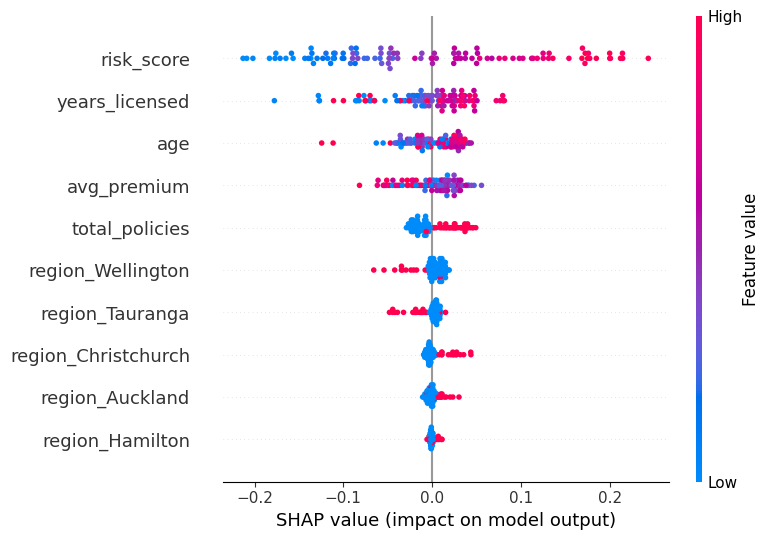

In [10]:
# SHAP for explainability
import shap
shap.initjs()

explainer = shap.TreeExplainer(best_rf)
shap_values = explainer.shap_values(X_test)

# class 1 (has claim) 추출
sv = shap_values[:, :, 1]  # shape: (60, 10)

# Summary plot
shap.summary_plot(sv, X_test)

# Force plot — single prediction
shap.force_plot(
    explainer.expected_value[1],
    sv[0],
    X_test.iloc[0]
)